<a href="https://colab.research.google.com/github/GayatriVidhate23/Pattern-Recognition-/blob/main/Practical_07(PR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytesseract
!pip install opencv-python


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving pr07.jpg to pr07.jpg


In [ ]:
import cv2
import matplotlib.pyplot as plt

images = {}

for filename in uploaded.keys():
    img = cv2.imread(filename)

    if img is None:
        print(f"Could not read {filename}")
        continue

    images[filename] = img

print("Total Images Uploaded:", len(images))

Total Images Uploaded: 1


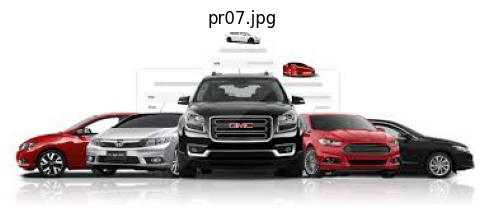

In [ ]:
for filename, img in images.items():

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,4))
    plt.imshow(img_rgb)
    plt.title(filename)
    plt.axis("off")
    plt.show()

Processing: pr07.jpg


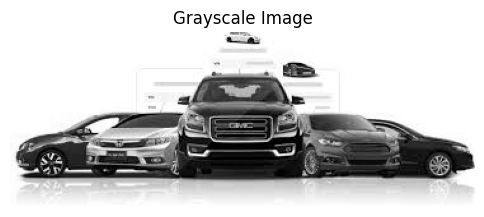

In [ ]:
for filename, img in images.items():

    print("Processing:", filename)

    # Your OCR or Number Plate Detection Code Here

    # Example
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(6,4))
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")
    plt.show()

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

image_folder = "/content/images"

for filename in os.listdir(image_folder):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        path = os.path.join(image_folder, filename)

        img = cv2.imread(path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6,4))
        plt.imshow(img)
        plt.title(filename)
        plt.axis("off")
        plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.8 MB/s eta 0:00:00


SUMMARY
Valid Plates : 0
Invalid Plates : 0


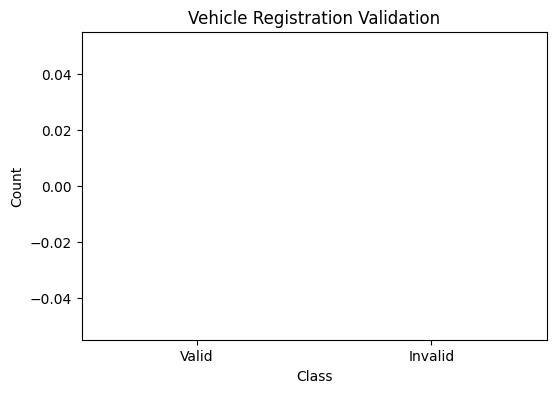

In [ ]:
!pip install anytree

import os
import cv2
import re
import pytesseract
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from anytree import Node, RenderTree

image_folder = "/content/images"
annotation_folder = "/content/annotations"

pattern = r'^[A-Z]{2}[0-9]{2}[A-Z]{1,3}[0-9]{4}$'

def validate_plate(text):

    text = text.upper()

    text = text.replace(" ","")

    text = text.replace("-","")

    if re.fullmatch(pattern,text):

        return True

    return False

def parse_tree(plate):

    plate = plate.replace(" ","")

    root = Node("Registration Number")

    Node("STATE : " + plate[:2], parent=root)

    Node("DISTRICT : " + plate[2:4], parent=root)

    letters = ""

    digits = ""

    for ch in plate[4:]:

        if ch.isalpha():

            letters += ch

        else:

            digits += ch

    Node("SERIES : " + letters, parent=root)

    Node("NUMBER : " + digits, parent=root)

    return root

def read_xml(xml_file):

    tree = ET.parse(xml_file)

    root = tree.getroot()

    xmin = int(root.find(".//xmin").text)

    ymin = int(root.find(".//ymin").text)

    xmax = int(root.find(".//xmax").text)

    ymax = int(root.find(".//ymax").text)

    return xmin,ymin,xmax,ymax

def OCR(img):

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    gray = cv2.GaussianBlur(gray,(3,3),0)

    _,th = cv2.threshold(gray,150,255,cv2.THRESH_BINARY)

    text = pytesseract.image_to_string(

        th,

        config="--psm 7"

    )

    return text.strip()

valid = 0

invalid = 0

files = sorted(os.listdir(image_folder))

for file in files:

    if not file.endswith(".png"):

        continue

    image_path = os.path.join(image_folder,file)

    xml_path = os.path.join(annotation_folder,

                            file.replace(".png",".xml"))

    image = cv2.imread(image_path)

    xmin,ymin,xmax,ymax = read_xml(xml_path)

    plate = image[ymin:ymax,xmin:xmax]

    text = OCR(plate)

    text = text.upper()

    text = text.replace(" ","")

    text = text.replace("-","")

    status = validate_plate(text)

    if status:

        valid += 1

    else:

        invalid += 1

    cv2.rectangle(

        image,

        (xmin,ymin),

        (xmax,ymax),

        (0,255,0),

        2

    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)

    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))

    plt.title("Vehicle Image")

    plt.axis("off")

    plt.subplot(1,2,2)

    plt.imshow(cv2.cvtColor(plate,cv2.COLOR_BGR2RGB))

    plt.title("Detected Plate")

    plt.axis("off")

    plt.show()

    print("="*60)

    print("Image :",file)

    print("OCR Output :",text)

    if status:

        print("STATUS : VALID")

        tree = parse_tree(text)

        print("\nPARSE TREE")

        for pre,fill,node in RenderTree(tree):

            print(pre + node.name)

    else:

        print("STATUS : INVALID")

print("\n")

print("="*50)

print("SUMMARY")

print("="*50)

print("Valid Plates :",valid)

print("Invalid Plates :",invalid)


plt.figure(figsize=(6,4))

plt.bar(

    ["Valid","Invalid"],

    [valid,invalid],

    color=["green","red"]

)

plt.title("Vehicle Registration Validation")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()